In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")

In [2]:
# Plot color
cols1 = sns.color_palette("Oranges", 2)
cols2 = sns.color_palette("Blues", 2)

In [3]:
# Load high-diversity data
df1 = pd.read_csv("../results/learning_loss/esm2_35M_high_batch128_constant_warmup0.0_lr5e-6.csv")
df1 = df1[df1.epoch.apply(lambda x: x % 5 == 0 or x == 1)]

# Load low-diversity data
df2 = pd.read_csv("../results/learning_loss/esm2_35M_low_batch128_constant_warmup0.0_lr5e-6.csv")
df2 = df2[df2.epoch.apply(lambda x: x % 5 == 0 or x == 1)]

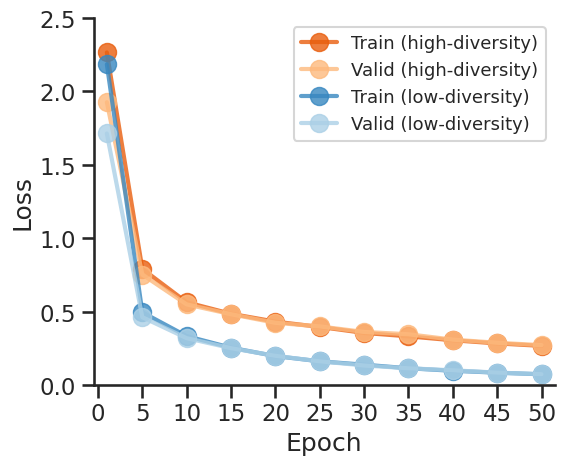

In [4]:
# loss
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(df1.epoch, df1.train_loss, "-o", markersize=13, linewidth=3.0, color=cols1[1], alpha=0.8, label="Train (high-diversity)")
ax.plot(df1.epoch, df1.valid_loss, "-o", markersize=13, linewidth=3.0, color=cols1[0], alpha=0.8, label="Valid (high-diversity)")
ax.plot(df2.epoch, df2.train_loss, "-o", markersize=13, linewidth=3.0, color=cols2[1], alpha=0.8, label="Train (low-diversity)")
ax.plot(df2.epoch, df2.valid_loss, "-o", markersize=13, linewidth=3.0, color=cols2[0], alpha=0.8, label="Valid (low-diversity)")
ax.set_xlim(-0.5, 51.5)
ax.set_xticks(np.arange(0, 51, 5))
ax.set_ylim(0, 2.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(loc="upper right", fontsize=13)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/loss_curves.svg")

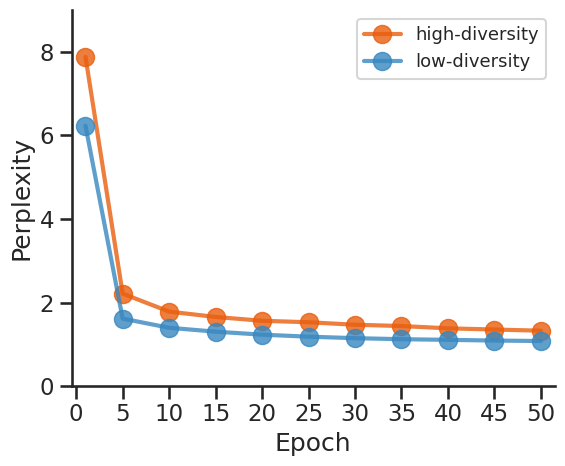

In [5]:
# Perplexity
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(df1.epoch, df1.perplexity, "-o", markersize=13, linewidth=3.0, color=cols1[1], alpha=0.8, label="high-diversity")
ax.plot(df2.epoch, df2.perplexity, "-o", markersize=13, linewidth=3.0, color=cols2[1], alpha=0.8, label="low-diversity")
ax.set_xlim(-0.5, 51.5)
ax.set_xticks(np.arange(0, 51, 5))
ax.set_ylim(0, 9)
ax.set_xlabel("Epoch")
ax.set_ylabel("Perplexity")
ax.legend(loc="upper right", fontsize=13)
sns.despine()
fig.tight_layout()
fig.savefig("./figures/perplexicity_curves.svg")